<a href="https://colab.research.google.com/github/Lzy200292/APN/blob/main/Heatwave_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Using machine learning to correct ERA5 data**

In [1]:
from functools import partial
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt
from datetime import datetime
import time
import pickle
import warnings
import gc
from scipy.stats import gaussian_kde

# Ignore warnings
warnings.filterwarnings('ignore')

# ---------------------------
# 1. Configuration parameters
# ---------------------------
era5_file = r'/content/17-24.csv'
station_file = r"/content/xujiahui.csv"
output_folder = r"/content/output" + datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
model_output_folder = os.path.join(output_folder, "models")
prediction_output_folder = os.path.join(output_folder, "predictions")
plot_output_folder = os.path.join(output_folder, "plots")
optimization_output_folder = os.path.join(output_folder, "optimization")
target_variable = 'T'  # target variable
era5_feature_vars = ['t2m', 'sp', 'ssrd','tcc' , 'strd', 'u10', 'v10', 'blh','d2m','sshf',
                     'valid_time', 'latitude', 'longitude']
station_radius = 0.1  # latitude/longitude matching radius

# Time range settings
train_start_year = 2017
train_end_year = 2024

random_state = 42
n_splits = 5  # number of cross-validation folds
n_estimators = 1000

# Test set ratio
test_size = 0.2

# XGBoost parameters
fixed_xgb_params = {
    'max_depth': 6,
    'learning_rate': 0.1,
    'gamma': 0,
    'min_child_weight': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'n_estimators': n_estimators,
    'objective': 'reg:squarederror',
    'random_state': random_state,
    'n_jobs': -1
}

# Feature-selection threshold; a negative value means no feature filtering
feature_importance_threshold = -1

# Station configuration, including prediction file paths
stations_config = [
    {
        "name": "xujiahui",
        "latitude": 31.1922,
        "longitude": 121.4317,
        "prediction_files": [r'/content/2016.csv'],
        "prediction_model_path": os.path.join(model_output_folder, "xgb_model_xujiahui_31.1922_121.4317.pkl")
    }
]

prediction_output_format = 'csv'  # output format: csv or excel

# Default feature names for prediction when not saved in the model file
DEFAULT_FEATURES = [
    't2m', 'sp', 'ssrd', 'strd', 'u10', 'v10', 'd2m', 'tcc', 'sshf',
    'wind_speed', 'temp_pressure', 'radiation_flux', 'blh', 'pbl_heat',
    'month', 'day', 'hour', 'season_sin', 'season_cos', 'hour_sin', 'hour_cos'
]


# ---------------------------
# 2. Output folder creation
# ---------------------------
def create_output_folders():
    """Create all required output folders"""
    folders = [output_folder, model_output_folder, prediction_output_folder, plot_output_folder,
               optimization_output_folder]
    for folder in folders:
        try:
            if not os.path.exists(folder):
                os.makedirs(folder)
                print(f"Created folder: {folder}")
        except Exception as e:
            print(f"Created folder {folder} failed: {str(e)}")


# ---------------------------
# 3. Data processing functions
# ---------------------------
def read_era5(file_path, feature_vars):
    """Read the ERA5 CSV file and preprocess the data"""
    try:
        df = pd.read_csv(file_path)
        missing_vars = [var for var in feature_vars if var not in df.columns]
        if missing_vars:
            print(f"Warning: The file is missing the following variables: {missing_vars}")
            # Add default values for missing variables
            for var in missing_vars:
                df[var] = 0.0
                print(f"Added default value for missing variable '{var}' ")

        df = df[feature_vars].copy()

        # Time-column processing: convert to datetime and split into features
        if 'valid_time' in df.columns:
            df['valid_time'] = pd.to_datetime(df['valid_time'])
            df['year'] = df['valid_time'].dt.year
            df['month'] = df['valid_time'].dt.month
            df['day'] = df['valid_time'].dt.day
            df['hour'] = df['valid_time'].dt.hour
            df = df.drop(columns=['valid_time'])  # drop the original time column
        else:
            print("Warning: Data is missing the 'valid_time' column; default time features will be added")
            df['year'] = 2000  # default year
            df['month'] = 1
            df['day'] = 1
            df['hour'] = 12

        # Convert numeric columns to float32 while keeping latitude/longitude precision
        for col in df.select_dtypes(include=['float64']).columns:
            if col not in ['latitude', 'longitude']:
                df[col] = df[col].astype('float32')

        return df
    except Exception as e:
        print(f"Failed to read ERA5 filefailed: {str(e)}")
        return None


def load_station_data(file_path):
    """Load a single station CSV file"""
    try:
        df = pd.read_csv(file_path)
        if target_variable not in df.columns:
            print(f"Warning: Station file is missing the target variable {target_variable}")
            return None, []

        # Time-column processing, if available
        if 'Time' in df.columns:
            df['Time'] = pd.to_datetime(df['Time'])
            df['station_year'] = df['Time'].dt.year
            df['station_month'] = df['Time'].dt.month
            df['station_day'] = df['Time'].dt.day
            df['station_hour'] = df['Time'].dt.hour
            df = df.drop(columns=['Time'])  # drop the original time column
        else:
            print("Warning: Station data is missing the time column; time matching cannot be performed")
            return None, []

        # Convert numeric columns to float32 while keeping latitude/longitude precision
        for col in df.select_dtypes(include=['float64']).columns:
            if col not in ['latitude', 'longitude']:
                df[col] = df[col].astype('float32')

        # Extract station coordinates
        stations = df.groupby(['latitude', 'longitude']).size().reset_index()
        stations = [(row['latitude'], row['longitude']) for _, row in stations.iterrows()]
        return df, stations
    except Exception as e:
        print(f"Failed to read station filefailed: {str(e)}")
        return None, []


def match_era5_station(era5_df, station_df, station_lat, station_lon, radius=0.1, year_filter=None):
    """Match ERA5 data with station data"""
    if station_df is None or era5_df is None:
        return None, None, None, None

    # Filter station data for the specified station
    station_data = station_df[(station_df['latitude'] == station_lat) & (station_df['longitude'] == station_lon)]
    if station_data.empty:
        print(f"Warning: station ({station_lat}, {station_lon}) has no valid data")
        return None, None, None, None

    # Year filtering
    if year_filter is not None:
        station_data = station_data[station_data['station_year'].isin(year_filter)]
        era5_df = era5_df[era5_df['year'].isin(year_filter)]
        if station_data.empty or era5_df.empty:
            print(f"Warning: No data after filtering years {year_filter}")
            return None, None, None, None

    era5_values = []
    station_values = []
    X_list, y_list = [], []

    for idx, row in station_data.iterrows():
        target_val = row[target_variable]
        if pd.isna(target_val):
            continue

        # Extract station time features for ERA5 matching
        station_year = row.get('station_year')
        station_month = row.get('station_month')
        station_day = row.get('station_day')
        station_hour = row.get('station_hour')

        # Latitude/longitude radius matching
        lat_mask = (era5_df['latitude'] >= station_lat - radius) & (era5_df['latitude'] <= station_lat + radius)
        lon_mask = (era5_df['longitude'] >= station_lon - radius) & (era5_df['longitude'] <= station_lon + radius)

        # Time matching
        time_mask = pd.Series([True] * len(era5_df))
        if station_year is not None:
            time_mask &= (era5_df['year'] == station_year)
        if station_month is not None:
            time_mask &= (era5_df['month'] == station_month)
        if station_day is not None:
            time_mask &= (era5_df['day'] == station_day)
        if station_hour is not None:
            time_mask &= (era5_df['hour'] == station_hour)

        matched = era5_df[lat_mask & lon_mask & time_mask]
        if not matched.empty:
            matched_row = matched.iloc[0].copy()
            era5_values.append(matched_row['t2m'])
            station_values.append(target_val)

            # Remove latitude/longitude columns after matching
            for col in ['latitude', 'longitude']:
                if col in matched_row.index:
                    matched_row = matched_row.drop(col)
            X_list.append(matched_row.values)
            y_list.append(target_val)

    if not X_list:
        print(f"Warning: station ({station_lat}, {station_lon}) matched no ERA5 data")
        return None, None, None, None

    X_df = pd.DataFrame(X_list, columns=matched_row.index)
    y_array = np.array(y_list, dtype='float32')

    return X_df, y_array, np.array(era5_values), np.array(station_values)


# ---------------------------
# Prepare prediction data
# ---------------------------
def prepare_prediction_data(file_path, feature_vars, station_lat, station_lon, radius=0.1, target_year=None):
    """Prepare prediction data; supports year filtering. If target_year=None, all years are returned"""
    print(f"\n===== Preparing prediction data: {file_path} =====")

    # Read ERA5 data
    era5_df = read_era5(file_path, feature_vars)
    if era5_df is None or era5_df.empty:
        print(f"Failed to read prediction data: {file_path}")
        return None, None, None

    # Filter the target year, if specified
    if target_year is not None:
        era5_df = era5_df[era5_df['year'] == target_year]
        if era5_df.empty:
            print(f"Warning: No prediction data for year {target_year}")
            return None, None, None

    # Filter ERA5 data within the specified coordinate range
    lat_mask = (era5_df['latitude'] >= station_lat - radius) & (era5_df['latitude'] <= station_lat + radius)
    lon_mask = (era5_df['longitude'] >= station_lon - radius) & (era5_df['longitude'] <= station_lon + radius)
    prediction_data = era5_df[lat_mask & lon_mask].copy()

    if prediction_data.empty:
        print(f"Warning: No ERA5 data was found near station coordinates ({station_lat}, {station_lon}) ")
        return None, None, None

    # Print data-count information
    if target_year:
        print(f"Found {len(prediction_data)} records of prediction data for year {target_year}")
    else:
        print(f"Found {len(prediction_data)} records of prediction data for all years")

    # Save raw temperature for comparison; convert Kelvin to Celsius
    original_temps = prediction_data['t2m'].values - 273.15

    # Save time and coordinate information
    time_info = {
        'year': prediction_data['year'].values,
        'month': prediction_data['month'].values,
        'day': prediction_data['day'].values,
        'hour': prediction_data['hour'].values
    }

    coordinates = {
        'latitude': prediction_data['latitude'].values,
        'longitude': prediction_data['longitude'].values
    }

    # Remove unnecessary columns
    drop_columns = ['latitude', 'longitude', 'year']
    for col in drop_columns:
        if col in prediction_data.columns:
            prediction_data = prediction_data.drop(columns=[col])

    # Keep time features for feature engineering
    print(f"Prepared prediction data features: {prediction_data.columns.tolist()}")
    return prediction_data, original_temps, (time_info, coordinates)


# ---------------------------
# 4. Feature engineering functions
# ---------------------------
def engineer_features(X_df, include_time_features=True):
    """Feature engineering: cyclic time features and physical features"""
    if not isinstance(X_df, (pd.DataFrame, np.ndarray)) or \
            (isinstance(X_df, pd.DataFrame) and X_df.empty) or \
            (isinstance(X_df, np.ndarray) and X_df.size == 0):
        return X_df

    if isinstance(X_df, np.ndarray):
        X_df = pd.DataFrame(X_df)

    # Physical features: wind speed and temperature-pressure product
    if 'u10' in X_df.columns and 'v10' in X_df.columns:
        X_df['wind_speed'] = np.sqrt(X_df['u10'] ** 2 + X_df['v10'] ** 2)
    else:
        print("Warning: Data is missing 'u10' or 'v10'; wind_speed cannot be calculated, so a default value will be added")
        X_df['wind_speed'] = 0.0

    if 't2m' in X_df.columns and 'sp' in X_df.columns:
        X_df['temp_pressure'] = X_df['t2m'] * X_df['sp']
    else:
        print("Warning: Data is missing 't2m' or 'sp'; temp_pressure cannot be calculated, so a default value will be added")
        X_df['temp_pressure'] = 0.0

    # Additional physical feature: combined radiation flux
    if 'ssrd' in X_df.columns and 'strd' in X_df.columns:
        X_df['radiation_flux'] = X_df['ssrd'] + X_df['strd']
    else:
        print("Warning: Data is missing 'ssrd' or 'strd'; radiation_flux cannot be calculated, so a default value will be added")
        X_df['radiation_flux'] = 0.0
    if 'blh' in X_df.columns and 't2m' in X_df.columns:
        X_df['pbl_heat'] = X_df['blh'] * X_df['t2m']  # thermal boundary-layer intensity indicator
    # Cyclic time features: monthly cycle
    if include_time_features:
        if 'month' in X_df.columns:
            X_df['season_sin'] = np.sin(2 * np.pi * X_df['month'] / 12)
            X_df['season_cos'] = np.cos(2 * np.pi * X_df['month'] / 12)
        else:
            print("Warning: Data is missing the 'month' feature; monthly cyclic features cannot be generated")
            # Add default values for missing time features
            X_df['month'] = 1  # default value: January
            X_df['season_sin'] = np.sin(2 * np.pi * X_df['month'] / 12)
            X_df['season_cos'] = np.cos(2 * np.pi * X_df['month'] / 12)
            print(
                f"Added default value 1 for 'month', default value for 'season_sin': {X_df['season_sin'][0]:.4f}; default value for 'season_cos': {X_df['season_cos'][0]:.4f}")

        # Cyclic time features: daily cycle
        if 'hour' in X_df.columns:
            X_df['hour_sin'] = np.sin(2 * np.pi * X_df['hour'] / 24)
            X_df['hour_cos'] = np.cos(2 * np.pi * X_df['hour'] / 24)
        else:
            print("Warning: Data is missing the 'hour' feature; daily cyclic features cannot be generated")
            # Add default values for missing time features
            X_df['hour'] = 12  # default value: 12:00 noon
            X_df['hour_sin'] = np.sin(2 * np.pi * X_df['hour'] / 24)
            X_df['hour_cos'] = np.cos(2 * np.pi * X_df['hour'] / 24)
            print(
                f"Added default value 12 for 'hour', default value for 'hour_sin': {X_df['hour_sin'][0]:.4f}; default value for 'hour_cos': {X_df['hour_cos'][0]:.4f}")

    # Fill missing values
    X_df = X_df.fillna(X_df.mean())
    print(f"Shape after feature engineering: {X_df.shape}，feature list: {X_df.columns.tolist()}")
    return X_df


def select_features(X, y=None, threshold=feature_importance_threshold, feature_names=None):
    """Feature selection: keep all features"""
    if feature_names is not None:
        if isinstance(X, pd.DataFrame):
            # Ensure all required features exist
            for feature in feature_names:
                if feature not in X.columns:
                    X[feature] = 0.0
                    print(f"Added default value 0.0 for missing feature '{feature}' ")
            return X[feature_names]
        else:
            return pd.DataFrame(X, columns=feature_names)

    if (isinstance(X, pd.DataFrame) and X.empty) or (isinstance(X, np.ndarray) and X.size == 0):
        print("Warning: Insufficient data for feature selection")
        return X

    # If the threshold is negative, keep all features
    if threshold < 0:
        print(f"Feature-selection threshold is negative; keeping all {X.shape[1]}  features")
        return X

    # Original feature-selection logic when the threshold is non-negative
    if y is not None:
        model = xgb.XGBRegressor(n_estimators=200, random_state=random_state)
        model.fit(X, y)

        importance_df = pd.DataFrame({
            'Feature': X.columns if isinstance(X, pd.DataFrame) else range(X.shape[1]),
            'Importance': model.feature_importances_
        }).sort_values('Importance', ascending=False)

        selected_features = importance_df[importance_df['Importance'] > threshold]['Feature'].tolist()
        print(
            f"Number of selected features: {len(selected_features)}/{len(X.columns) if isinstance(X, pd.DataFrame) else X.shape[1]}")

        if isinstance(X, np.ndarray):
            if len(selected_features) > 0:
                return X[:, selected_features]
            else:
                return X
        else:
            return X[selected_features] if len(selected_features) > 0 else X
    else:
        print("Warning: No target variable was provided; all available features will be used for prediction")
        return X


# ---------------------------
# 5. XGBoost model functions
# ---------------------------
def train_xgb_model(X, y):
    """Train an XGBoost model using fixed parameters"""
    if (isinstance(X, pd.DataFrame) and X.empty) or (isinstance(X, np.ndarray) and X.size == 0) or len(y) < 10:
        print("Warning: Insufficient data to train the model")
        return None

    model = xgb.XGBRegressor(**fixed_xgb_params)
    model.fit(X, y)
    return model


def evaluate_xgb_model(model, X_train, y_train, X_test, y_test):
    """Evaluate the XGBoost model"""
    if model is None:
        return None, None, None, None, None, None, None, None

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    print("\nTraining set evaluation:")
    print(f"R²: {train_r2:.4f}, MAE: {train_mae:.4f}")
    print("Test set evaluation:")
    print(f"R²: {test_r2:.4f}, MAE: {test_mae:.4f}")

    return y_train_pred, y_test_pred, y_train, y_test, train_r2, train_mae, test_r2, test_mae


def cross_validate_xgb_model(X, y, n_splits=5, random_state=42):
    """Evaluate the XGBoost model using K-fold cross-validation"""
    print(f"\n===== Running {n_splits}-fold cross-validation =====")

    # Initialize the KFold object
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Store evaluation results for each fold
    cv_results = []
    feature_importance_list = []

    # Standardize data; use a pipeline-like process to reduce leakage risk
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Run cross-validation
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_scaled, y)):
        print(f"\n===== Cross-validation fold {fold_idx + 1}/{n_splits} =====")

        # Get training and validation sets
        X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Model training
        model = train_xgb_model(X_train, y_train)
        if model is None:
            print(f"Warning: Fold {fold_idx + 1} training failed; skipped")
            continue

        # Model evaluation
        y_val_pred = model.predict(X_val)
        val_r2 = r2_score(y_val, y_val_pred)
        val_mae = mean_absolute_error(y_val, y_val_pred)

        # Save evaluation results and feature importance
        cv_results.append((val_r2, val_mae))
        feature_importance_list.append(model.feature_importances_)

        print(f"Fold {fold_idx + 1}/{n_splits}: R²={val_r2:.4f}, MAE={val_mae:.4f}")

    # Calculate average performance
    if cv_results:
        avg_r2 = np.mean([r2 for r2, _ in cv_results])
        avg_mae = np.mean([mae for _, mae in cv_results])
        std_r2 = np.std([r2 for r2, _ in cv_results])
        std_mae = np.std([mae for _, mae in cv_results])

        print(f"\nCross-validation average performance: R²={avg_r2:.4f}±{std_r2:.4f}, MAE={avg_mae:.4f}±{std_mae:.4f}")

        # Calculate average feature importance
        if feature_importance_list and isinstance(X, pd.DataFrame):
            avg_importance = np.mean(feature_importance_list, axis=0)
            importance_df = pd.DataFrame({
                'Feature': X.columns,
                'Importance': avg_importance
            }).sort_values('Importance', ascending=False)

            importance_path = os.path.join(output_folder, f"cross_validation_feature_importance.csv")
            importance_df.to_csv(importance_path, index=False)
            print(f"Cross-validation feature importance saved to: {importance_path}")

            # Plot feature importance
            plot_feature_importance(importance_df,
                                    os.path.join(plot_output_folder, f"cross_validation_feature_importance.png"))

        return cv_results, avg_r2, avg_mae
    else:
        print("Warning: Cross-validation produced no valid results")
        return None, None, None


def plot_feature_importance(importance_df, save_path, top_n=20):
    """Plot feature importance"""
    plt.figure(figsize=(10, 6))

    # Use the top_n features
    plot_df = importance_df.head(top_n).sort_values('Importance')

    plt.barh(plot_df['Feature'], plot_df['Importance'])
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title('XGBoost Feature Importance')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    plt.savefig(save_path, dpi=300)
    plt.close()


def plot_prediction(actual, predicted, r2, mae, title, save_path):
    """Plot prediction results with R² and MAE, color points by density, and remove outliers"""
    # Calculate the difference between predicted and raw values, i.e., correction amount
    corrections = predicted - actual

    # Define the outlier threshold: absolute correction greater than 10 °C
    outlier_threshold = 10.0

    # Mark outliers
    is_outlier = np.abs(corrections) > outlier_threshold

    # Remove outliers
    actual_filtered = actual[~is_outlier]
    predicted_filtered = predicted[~is_outlier]
    corrections_filtered = corrections[~is_outlier]

    # Calculate metrics after removing outliers
    r2_filtered = r2_score(actual_filtered, predicted_filtered)
    mae_filtered = mean_absolute_error(actual_filtered, predicted_filtered)

    plt.figure(figsize=(8, 6))

    # Calculate point density
    if len(actual_filtered) > 1:
        # Use kernel density estimation to calculate point density
        points = np.vstack([actual_filtered, predicted_filtered])
        kde = gaussian_kde(points)
        density = kde(points)
        # Normalize density values for color mapping
        density = (density - density.min()) / (density.max() - density.min())
    else:
        density = np.ones(len(actual_filtered))  # use a uniform color when there is one point or no point

    # Plot scatter points, with color indicating density
    scatter = plt.scatter(actual_filtered, predicted_filtered, c=density, alpha=0.8, cmap='viridis', edgecolors='none')

    # Add a diagonal reference line
    plt.plot([actual_filtered.min(), actual_filtered.max()],
             [actual_filtered.min(), actual_filtered.max()], 'r--', linewidth=2)

    # Annotate R² and MAE using the metrics after outlier removal
    plt.text(0.05, 0.95, f'R² = {r2_filtered:.4f}\nMAE = {mae_filtered:.4f}', transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', alpha=0.8), fontsize=12)

    # Set plot properties
    plt.title(title, fontsize=14)
    plt.xlabel("Observed / Reference Temperature (°C)", fontsize=12)
    plt.ylabel("Predicted Temperature (°C)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add outlier information
    outlier_count = np.sum(is_outlier)
    total_count = len(actual)
    plt.text(0.05, 0.05,
             f"Total records: {total_count}\n"
             f"Outliers: {outlier_count} ({outlier_count / total_count * 100:.2f}%)\n"
             f"Outlier threshold: |correction| > {outlier_threshold} °C",
             transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', alpha=0.8), fontsize=10)

    # Add a colorbar for point density
    cbar = plt.colorbar(scatter, label='Point density')
    cbar.set_label('Density', rotation=90, labelpad=15)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

    # Return outlier information
    return outlier_count


# ---------------------------
# Plot the comparison between raw ERA5 and station data
# ---------------------------
def plot_raw_comparison(era5_data, station_data, title, save_path):
    """Plot the comparison between raw ERA5 data and station data"""
    plt.figure(figsize=(8, 6))

    # Calculate point density
    if len(era5_data) > 1:
        points = np.vstack([era5_data, station_data])
        kde = gaussian_kde(points)
        density = kde(points)
        density = (density - density.min()) / (density.max() - density.min())
    else:
        density = np.ones(len(era5_data))

    # Plot scatter points, with color indicating density
    scatter = plt.scatter(era5_data, station_data, c=density, alpha=0.8, cmap='viridis', edgecolors='none')

    # Add a diagonal reference line for the ideal case
    min_val = min(era5_data.min(), station_data.min())
    max_val = max(era5_data.max(), station_data.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

    # Calculate and annotate R² and MAE
    r2 = r2_score(station_data, era5_data)
    mae = mean_absolute_error(station_data, era5_data)
    plt.text(0.05, 0.95, f'R² = {r2:.4f}\nMAE = {mae:.4f}', transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', alpha=0.8), fontsize=12)

    # Set plot properties
    plt.title(title, fontsize=14)
    plt.xlabel("ERA5 Raw Temperature (°C)", fontsize=12)
    plt.ylabel("Station Observed Temperature (°C)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Add summary statistics
    plt.text(0.05, 0.05,
             f"Number of pairs: {len(era5_data)}\n"
             f"ERA5 range: {era5_data.min():.2f} °C to {era5_data.max():.2f} °C\n"
             f"Station range: {station_data.min():.2f} °C to {station_data.max():.2f} °C",
             transform=plt.gca().transAxes,
             bbox=dict(facecolor='white', alpha=0.8), fontsize=10)

    # Add a colorbar for point density
    cbar = plt.colorbar(scatter, label='Point density')
    cbar.set_label('Density', rotation=90, labelpad=15)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.close()

    return r2, mae


# ---------------------------
# Data validation and report
# ---------------------------
def validate_data(era5_temps, station_temps, station_name):
    """Validate data quality and print a report"""
    print(f"\n===== {station_name} data validation report =====")

    # Calculate basic statistics
    era5_mean = np.mean(era5_temps)
    station_mean = np.mean(station_temps)
    era5_std = np.std(era5_temps)
    station_std = np.std(station_temps)
    corr = np.corrcoef(era5_temps, station_temps)[0, 1]

    # Print statistics
    print(
        f"ERA5 temperature statistics: mean={era5_mean:.2f}℃, standard deviation={era5_std:.2f}℃, range={np.min(era5_temps):.2f}~{np.max(era5_temps):.2f}℃")
    print(
        f"Station temperature statistics: mean={station_mean:.2f}℃, standard deviation={station_std:.2f}℃, range={np.min(station_temps):.2f}~{np.max(station_temps):.2f}℃")
    print(f"Correlation coefficient: {corr:.4f}")

    # Check outliers, assuming the valid temperature range is -40 °C to 50 °C
    era5_outliers = np.sum((era5_temps < -40) | (era5_temps > 50))
    station_outliers = np.sum((station_temps < -40) | (station_temps > 50))

    if era5_outliers > 0:
        print(f"Warning: possible outliers found in ERA5 data: {era5_outliers}")
    if station_outliers > 0:
        print(f"Warning: possible outliers found in station data: {station_outliers}")

    # Calculate bias
    bias = np.mean(era5_temps - station_temps)
    print(f"Mean bias (ERA5 - station): {bias:.2f}℃")

    return {
        'era5_mean': era5_mean,
        'station_mean': station_mean,
        'correlation': corr,
        'bias': bias,
        'era5_outliers': era5_outliers,
        'station_outliers': station_outliers
    }


# ---------------------------
# Load model
# ---------------------------
def load_model(model_path=None, station_id=None):
    """Load a trained XGBoost model and scaler with safe unpacking"""
    try:
        # Parameter validation
        if model_path is None and station_id is None:
            print("Error: A model path or station ID must be provided")
            return None, None, None

        # If no model path is specified, try to find the latest model
        if model_path is None and station_id is not None:
            model_folder = model_output_folder
            if not os.path.exists(model_folder):
                print(f"Error: Model folder does not exist: {model_folder}")
                return None, None, None

            # Find the latest model matching the station ID
            model_files = [f for f in os.listdir(model_folder) if
                           f.startswith(f"xgb_model_{station_id}") and f.endswith(".pkl")]
            if not model_files:
                print(f"Error: No model found for station {station_id} ")
                return None, None, None

            # Sort by modification time and select the latest model
            model_files.sort(key=lambda x: os.path.getmtime(os.path.join(model_folder, x)), reverse=True)
            model_path = os.path.join(model_folder, model_files[0])
            print(f"Using latest model: {model_path}")

        # Load model file
        if not os.path.exists(model_path):
            print(f"Error: Model file does not exist: {model_path}")
            return None, None, None

        with open(model_path, 'rb') as f:
            model_data = pickle.load(f)

        # Check model data type and length
        if not isinstance(model_data, (list, tuple)):
            print(f"Error: Invalid model file format; expected a list or tuple, got {type(model_data)}")
            return None, None, None

        # Unpack according to tuple/list length
        data_len = len(model_data)
        if data_len == 3:  # new format: model, scaler, feature names
            model, scaler, feature_names = model_data
            print(f"Loaded new-format model with {data_len}  elements")
        elif data_len == 2:  # old format: model, scaler
            model, scaler = model_data
            feature_names = DEFAULT_FEATURES  # use default feature names
            print(f"Loaded old-format model with {data_len}  elements; using the default feature list")
        else:
            print(f"Error: Model file contains {data_len}  elements; expected 2 or 3 elements")
            return None, None, None

        # Validate model and scaler
        if model is None or scaler is None:
            print("Error: Model or scaler is None")
            return None, None, None

        # Ensure feature names are valid
        if not feature_names or not isinstance(feature_names, list):
            print("Warning: Invalid feature names; using the default feature list")
            feature_names = DEFAULT_FEATURES

        print(f"Model loaded successfully; number of features: {len(feature_names)}")
        return model, scaler, feature_names

    except Exception as e:
        print(f"Failed to load modelfailed: {str(e)}")
        return None, None, None


# ---------------------------
# Predict and save results; supports year-wise saving and merged results
# ---------------------------
def predict_and_save(model, scaler, prediction_data, original_temps, time_info, coordinates, station_name, file_path,
                     feature_names=None, year=None, return_df=False):
    """Predict new data and save results; supports returning a DataFrame for merging"""
    if model is None or scaler is None or prediction_data is None:
        print("Error: Model, scaler, or prediction data is None")
        if return_df:
            return None
        return False

    # Feature engineering, consistent with training
    X_engineered = engineer_features(prediction_data, include_time_features=True)

    # Print the feature list after feature engineering
    print(f"Feature list after feature engineering: {list(X_engineered.columns)}")

    # Feature matching and selection
    if hasattr(scaler, 'feature_names_in_'):
        # Prefer features used when the scaler was fitted
        scaler_features = list(scaler.feature_names_in_)
        print(f"Features used when fitting the scaler: {scaler_features}")

        # 1. Ensure engineered data contains the features required by the scaler
        missing_features = set(scaler_features) - set(X_engineered.columns)
        if missing_features:
            print(f"Warning: Prediction data is missing the following features required by the scaler: {missing_features}")

            # Add missing features and fill with default values
            for feature in missing_features:
                if feature in ['season_sin', 'season_cos', 'hour_sin', 'hour_cos']:
                    X_engineered[feature] = 0.0
                elif feature in ['wind_speed', 'temp_pressure', 'radiation_flux']:
                    X_engineered[feature] = 0.0
                else:
                    # For other features, use the column mean
                    X_engineered[feature] = X_engineered.mean().get(feature, 0.0)
                print(f"Added a default value for missing feature '{feature}'")

        # 2. Remove extra features and keep only scaler-required features
        X_selected = X_engineered[scaler_features]

        # 3. Validate feature order and names
        if list(X_selected.columns) != scaler_features:
            print(f"Warning: Feature order mismatch; trying to reorder")
            try:
                X_selected = X_selected.reindex(columns=scaler_features)
                print("Feature order reordered successfully")
            except Exception as e:
                print(f"Failed to reorder featuresfailed: {e}")
                if return_df:
                    return None
                return False
    elif feature_names is not None:
        print(f"Using features from model training: {feature_names}")

        # 1. Ensure engineered data contains all required features
        missing_features = set(feature_names) - set(X_engineered.columns)
        if missing_features:
            print(f"Warning: Prediction data is missing the following features: {missing_features}")

            # Add missing features and fill with default values
            for feature in missing_features:
                if feature in ['season_sin', 'season_cos', 'hour_sin', 'hour_cos']:
                    X_engineered[feature] = 0.0
                elif feature in ['wind_speed', 'temp_pressure', 'radiation_flux']:
                    X_engineered[feature] = 0.0
                else:
                    X_engineered[feature] = X_engineered.mean().get(feature, 0.0)
                print(f"Added a default value for missing feature '{feature}'")

        # 2. Remove extra features
        extra_features = set(X_engineered.columns) - set(feature_names)
        if extra_features:
            print(f"Warning: Prediction data contains extra features: {extra_features} - these features will be removed")
            X_engineered = X_engineered.drop(columns=list(extra_features))

        # 3. Ensure consistent feature order
        X_selected = X_engineered[feature_names]

        # 4. Validate feature order and names
        if list(X_selected.columns) != feature_names:
            print(f"Error: Feature order mismatch")
            print(f"Expected order: {feature_names}")
            print(f"Actual order: {list(X_selected.columns)}")

            # Try to force feature reordering
            try:
                X_selected = X_selected.reindex(columns=feature_names)
                print("Feature order reordered successfully")
            except Exception as e:
                print(f"Failed to reorder featuresfailed: {e}")
                if return_df:
                    return None
                return False
    else:
        print("Warning: No feature names were provided; all available features will be used for prediction")
        X_selected = X_engineered

    # Print final feature list
    print(f"Final features used for prediction ({len(X_selected.columns)}): {list(X_selected.columns)}")

    # Check whether the data is valid
    if X_selected.empty or X_selected.isna().all().all():
        print("Error: Processed prediction data is empty or all NaN")
        if return_df:
            return None
        return False

    # Data standardization
    try:
        print(f"Data standardization: using the scaler to process {X_selected.shape[0]} records and {X_selected.shape[1]} features")
        X_scaled = scaler.transform(X_selected)
        print(f"Shape after standardization: {X_scaled.shape}")
    except ValueError as e:
        print(f"Data standardization error: {e}")
        print(f"Prediction data shape: {X_selected.shape}")
        print(f"Prediction data columns: {X_selected.columns.tolist()}")

        # Check scaler features
        if hasattr(scaler, 'feature_names_in_'):
            print(f"Features used when fitting the scaler: {list(scaler.feature_names_in_)}")
            print(f"Number of features expected by the scaler: {len(scaler.feature_names_in_)}")

        # Check model features
        if hasattr(model, 'n_features_in_'):
            print(f"Features used when training the model: {list(model.feature_names_in_)}")
            print(f"Number of features expected by the model: {model.n_features_in_}")

        if return_df:
            return None
        return False

    # Prediction
    try:
        print(f"Model prediction: using {X_scaled.shape[1]} features to predict {X_scaled.shape[0]} records")
        predictions = model.predict(X_scaled)
        print(f"Prediction completed; result shape: {predictions.shape}")
    except Exception as e:
        print(f"Model prediction error: {e}")
        print(f"Input data shape: {X_scaled.shape}, number of features: {len(X_selected.columns)}")
        if hasattr(model, 'n_features_in_'):
            print(f"Number of features expected by the model: {model.n_features_in_}")
        if return_df:
            return None
        return False

    # Check whether prediction length matches raw temperature length
    if len(predictions) != len(original_temps):
        print(f"Warning: prediction length ({len(predictions)}) does not match raw temperature length ({len(original_temps)}); trying to truncate or pad")

        # Use the shorter length as the reference
        min_length = min(len(predictions), len(original_temps))
        predictions = predictions[:min_length]
        original_temps = original_temps[:min_length]

        # Truncate time and coordinate information
        for key in time_info:
            time_info[key] = time_info[key][:min_length]
        for key in coordinates:
            coordinates[key] = coordinates[key][:min_length]

        print(f"Data truncated to {min_length} records to ensure consistent length")

    # Create result DataFrame
    result_df = pd.DataFrame({
        'Year': time_info['year'],
        'Month': time_info['month'],
        'Day': time_info['day'],
        'Hour': time_info['hour'],
        'Latitude': coordinates['latitude'],
        'Longitude': coordinates['longitude'],
        'ERA5_raw_temperature_C': original_temps,
        'Corrected_temperature_C': predictions,
        'Temperature_correction_C': predictions - original_temps
    })

    # If only a DataFrame is needed for merging, do not save a single-year file
    if return_df:
        return result_df

    # Save single-year results
    base_filename = os.path.basename(file_path).split('.')[0]
    if year:
        output_filename = f"{station_name}_{year}"  # add year to filename
    else:
        output_filename = f"{station_name}"

    # Correct output-format handling logic
    output_format = prediction_output_format.lower()
    if output_format == 'csv':
        output_path = os.path.join(prediction_output_folder, f"{output_filename}.csv")
        result_df.to_csv(output_path, index=False, encoding='utf-8-sig')
    elif output_format == 'excel':
        output_path = os.path.join(prediction_output_folder, f"{output_filename}.xlsx")
        result_df.to_excel(output_path, index=False)
    else:
        print(f"Unsupported output format: {prediction_output_format}; CSV format will be used")
        output_path = os.path.join(prediction_output_folder, f"{output_filename}.csv")
        result_df.to_csv(output_path, index=False, encoding='utf-8-sig')

    print(f"Single-year prediction results saved to: {output_path}")

    # Plot prediction results; title includes the year
    plot_title = f"{station_name} Temperature Prediction in {year}\n(Raw ERA5 vs Corrected Temperature)" if year else f"{station_name} Temperature Prediction\n(Raw ERA5 vs Corrected Temperature)"
    plot_path = os.path.join(plot_output_folder, f"prediction_{output_filename}.png")
    plot_prediction(original_temps, predictions,
                    r2_score(original_temps, predictions),
                    mean_absolute_error(original_temps, predictions),
                    plot_title,
                    plot_path)
    print(f"Single-year prediction plot saved to: {plot_path}")

    return True


# New: directly save an existing prediction-result DataFrame
def save_prediction_df(year_df, station_name, file_path, year):
    """Directly save an existing prediction-result DataFrame to avoid repeated prediction"""
    if year_df is None or year_df.empty:
        print("Error: Prediction-result DataFrame is empty")
        return False

    # Save single-year results
    base_filename = os.path.basename(file_path).split('.')[0]
    output_filename = f"{station_name}_{year}"

    # Correct output-format handling logic
    output_format = prediction_output_format.lower()
    if output_format == 'csv':
        output_path = os.path.join(prediction_output_folder, f"{output_filename}.csv")
        year_df.to_csv(output_path, index=False, encoding='utf-8-sig')
    elif output_format == 'excel':
        output_path = os.path.join(prediction_output_folder, f"{output_filename}.xlsx")
        year_df.to_excel(output_path, index=False)
    else:
        print(f"Unsupported output format: {prediction_output_format}; CSV format will be used")
        output_path = os.path.join(prediction_output_folder, f"{output_filename}.csv")
        year_df.to_csv(output_path, index=False, encoding='utf-8-sig')

    print(f"Single-year prediction results saved to: {output_path}")

    # Plot prediction results; title includes the year
    original_temps = year_df['ERA5_raw_temperature_C'].values
    predictions = year_df['Corrected_temperature_C'].values
    plot_title = f"{station_name} Temperature Prediction in {year}\n(Raw ERA5 vs Corrected Temperature)"
    plot_path = os.path.join(plot_output_folder, f"prediction_{output_filename}.png")
    plot_prediction(original_temps, predictions,
                    r2_score(original_temps, predictions),
                    mean_absolute_error(original_temps, predictions),
                    plot_title,
                    plot_path)
    print(f"Single-year prediction plot saved to: {plot_path}")

    return True


# ---------------------------
# Merge multi-year prediction results and save
# ---------------------------
def merge_and_save_all_years(station_name, file_path, all_years_dfs):
    """Merge all yearly prediction results and save them as one complete file"""
    if not all_years_dfs or any(df is None for df in all_years_dfs):
        print("Warning: No valid data is available for merging all yearly results")
        return False

    # Merge DataFrames for all years
    merged_df = pd.concat(all_years_dfs, ignore_index=True)
    print(f"Successfully merged all yearly data; total records: {len(merged_df)}")

    # Sort by time: year-month-day-hour
    try:
        merged_df = merged_df.sort_values(by=['Year', 'Month', 'Day', 'Hour'])
        print("Merged results sorted by time")
    except Exception as e:
        print(f"Failed to sort merged resultsfailed: {e}; using the original order")

    # Generate merged-result filename
    base_filename = os.path.basename(file_path).split('.')[0]
    output_filename = f"{base_filename}_{station_name}"

    # Save merged results
    output_format = prediction_output_format.lower()
    if output_format == 'csv':
        output_path = os.path.join(prediction_output_folder, f"{output_filename}.csv")
        merged_df.to_csv(output_path, index=False, encoding='utf-8-sig')
    elif output_format == 'excel':
        output_path = os.path.join(prediction_output_folder, f"{output_filename}.xlsx")
        merged_df.to_excel(output_path, index=False)
    else:
        print(f"Unsupported output format: {prediction_output_format}; CSV format will be used")
        output_path = os.path.join(prediction_output_folder, f"{output_filename}.csv")
        merged_df.to_csv(output_path, index=False, encoding='utf-8-sig')

    print(f"Merged all-year results saved to: {output_path}")

    # Plot the overall prediction results for merged data
    original_temps = merged_df['ERA5_raw_temperature_C'].values
    predicted_temps = merged_df['Corrected_temperature_C'].values

    plot_title = f"{station_name} Temperature Prediction for All Years\n(Raw ERA5 vs Corrected Temperature, n = {len(merged_df)})"
    plot_path = os.path.join(plot_output_folder, f"prediction_{output_filename}.png")
    plot_prediction(original_temps, predicted_temps,
                    r2_score(original_temps, predicted_temps),
                    mean_absolute_error(original_temps, predicted_temps),
                    plot_title,
                    plot_path)
    print(f"Merged all-year prediction plot saved to: {plot_path}")

    return True


# ---------------------------
# 6. Main workflow; supports multi-year prediction and merged results
# ---------------------------
if __name__ == "__main__":
    start_time = time.time()
    print("Starting XGBoost meteorological prediction workflow...")

    # Set figure resolution and font
    plt.rcParams['figure.dpi'] = 300
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.sans-serif'] = ['Arial']
    plt.rcParams['axes.unicode_minus'] = False

    try:
        # Create output folders
        create_output_folders()

        # Read data
        print("\n===== Reading ERA5 data =====")
        era5_features = read_era5(era5_file, era5_feature_vars)
        if era5_features is None or era5_features.empty:
            print("Failed to read ERA5 data; program terminated")
            exit(1)

        print("\n===== Reading station data =====")
        station_df, all_stations = load_station_data(station_file)
        if station_df is None or station_df.empty:
            print("Failed to read station data; program terminated")
            exit(1)

        # Process each station
        for station_config in stations_config:
            station_name = station_config["name"]
            lat = station_config["latitude"]
            lon = station_config["longitude"]
            station_id = f"{station_name}_{lat}_{lon}"
            print(f"\n\n===== Processing station: {station_id} =====")

            # Data matching
            X, y, era5_temps, station_temps = match_era5_station(era5_features, station_df, lat, lon, station_radius)
            if X is None or y is None or len(X) < 10:
                print(f"Station {station_id} has insufficient valid data ({len(X)} records); skipped")
                continue

            # Convert ERA5 temperature from Kelvin to Celsius
            era5_temps_c = era5_temps - 273.15
            print(f"ERA5 temperature has been converted from Kelvin to Celsius (formula: °C = K - 273.15)")

            # Ensure data lengths are consistent before and after correction
            valid_indices = ~np.isnan(era5_temps_c) & ~np.isnan(station_temps)
            era5_temps_c_valid = era5_temps_c[valid_indices]
            station_temps_valid = station_temps[valid_indices]

            # Use only valid data for subsequent analysis
            print(f"Using valid data: {np.sum(valid_indices)}/{len(era5_temps_c)} pairs")

            # Skip this station if valid data are insufficient
            if len(era5_temps_c_valid) < 10:
                print(f"Station {station_id} has too few valid records ({len(era5_temps_c_valid)} records); skipped")
                continue

            # Data splitting
            indices = np.arange(len(X))
            train_indices, test_indices = train_test_split(
                indices[valid_indices],
                test_size=test_size,
                random_state=random_state,
                shuffle=True
            )

            # Extract ERA5 and station temperatures for the test set
            era5_test_temps = era5_temps_c_valid[test_indices]
            station_test_temps = station_temps_valid[test_indices]

            print(f"Test set size: {len(test_indices)}  pairs")

            # Data validation
            validation = validate_data(era5_test_temps, station_test_temps, station_name)

            # Plot the comparison between raw ERA5 and station data
            raw_comparison_path = os.path.join(plot_output_folder, f"raw_era5_vs_station_{station_id}.png")
            print("\n===== Plotting raw ERA5 versus station-data comparison =====")
            raw_r2, raw_mae = plot_raw_comparison(
                era5_test_temps,
                station_test_temps,
                f"{station_name}: Raw ERA5 Temperature vs Station Observation\n(Test set, mean bias: {validation['bias']:.2f} °C, n = {len(era5_test_temps)})",
                raw_comparison_path
            )
            print(f"Raw data comparison plot saved to: {raw_comparison_path}")
            print(f"Raw data evaluation: R² = {raw_r2:.4f}, MAE = {raw_mae:.4f}")

            # Feature engineering
            X_engineered = engineer_features(X)

            # Save feature names for prediction
            feature_names = X_engineered.columns.tolist()
            print(f"Features used for training: {feature_names}")

            # Feature selection
            X_selected = select_features(X_engineered, y)

            # Data splitting
            X_train = X_selected.iloc[train_indices]
            X_test = X_selected.iloc[test_indices]
            y_train = y[train_indices]
            y_test = y[test_indices]

            print(f"Data split: training set {len(X_train)} records, test set {len(X_test)} records")
            print(f"Number of training features: {X_train.shape[1]}")

            # Data standardization
            scaler = StandardScaler()
            # Fit scaler and record feature names
            scaler.fit(X_train)
            if hasattr(scaler, 'feature_names_in_'):
                print(f"Feature names recorded by scaler: {list(scaler.feature_names_in_)}")
            else:
                # Manually record feature names for scikit-learn versions without feature_names_in_
                scaler.feature_names_in_ = X_train.columns.tolist()
                print(f"Manually recorded scaler feature names: {scaler.feature_names_in_}")

            X_train_scaled = scaler.transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            # Run 5-fold cross-validation
            print("\n===== Running 5-fold cross-validation =====")
            cv_results, avg_r2, avg_mae = cross_validate_xgb_model(X_selected, y, n_splits=n_splits,
                                                                   random_state=random_state)

            # Model training
            print("\n===== Training XGBoost model =====")
            print("Using fixed parameters:")
            for param, value in fixed_xgb_params.items():
                print(f"  {param}: {value}")

            xgb_model = train_xgb_model(X_train_scaled, y_train)
            if xgb_model is None:
                continue

            # Model evaluation
            print("\n===== Evaluating model =====")
            eval_results = evaluate_xgb_model(xgb_model, X_train_scaled, y_train, X_test_scaled, y_test)

            # Check whether evaluation results were unpacked correctly
            if eval_results is None or len(eval_results) != 8:
                print("Warning: Invalid model evaluation result format")
                y_test_pred = None
            else:
                y_train_pred, y_test_pred, y_train_true, y_test_true, train_r2, train_mae, test_r2, test_mae = eval_results

            if y_test_pred is None:
                continue

            # Calculate model improvement
            mae_improvement = (raw_mae - test_mae) / raw_mae * 100
            r2_improvement = (test_r2 - raw_r2) / (1 - raw_r2) * 100 if raw_r2 < 1 else float('inf')
            print(f"\nModel improvement:")
            print(f"MAE reduction: {mae_improvement:.2f}%")
            print(f"R² improvement: {r2_improvement:.2f}%")

            # Plot training-set prediction results
            train_plot_path = os.path.join(plot_output_folder, f"train_prediction_{station_id}.png")
            plot_prediction(y_train_true, y_train_pred, train_r2, train_mae,
                            f"{station_name} Training Set Prediction\n(R²={train_r2:.4f}, MAE={train_mae:.4f})",
                            train_plot_path)
            print(f"Training-set prediction plot saved to: {train_plot_path}")

            # Plot test-set prediction results
            test_plot_path = os.path.join(plot_output_folder, f"test_prediction_{station_id}.png")
            plot_prediction(y_test_true, y_test_pred, test_r2, test_mae,
                            f"{station_name} Test Set Prediction\n(R²={test_r2:.4f}, MAE={test_mae:.4f})",
                            test_plot_path)
            print(f"Test-set prediction plot saved to: {test_plot_path}")

            # Save model and feature names, ensuring format consistency
            model_path = os.path.join(model_output_folder, f"xgb_model_{station_id}.pkl")
            try:
                # Ensure a three-element tuple is saved
                model_data = (xgb_model, scaler, feature_names)
                with open(model_path, 'wb') as f:
                    pickle.dump(model_data, f)
                print(f"Model saved to: {model_path} (format: three-element tuple)")
            except Exception as e:
                print(f"Failed to save modelfailed: {str(e)}")

            # Output feature importance
            if hasattr(xgb_model, 'feature_importances_'):
                importance_df = pd.DataFrame({
                    'Feature': X_selected.columns,
                    'Importance': xgb_model.feature_importances_
                }).sort_values('Importance', ascending=False)
                importance_path = os.path.join(output_folder, f"feature_importance_{station_id}.csv")
                importance_df.to_csv(importance_path, index=False)
                print(f"Feature importance saved to: {importance_path}")
                print("Top 5 most important features:")
                for _, row in importance_df.head(5).iterrows():
                    print(f"  {row['Feature']}: {row['Importance']:.4f}")

            # ---------------------------
            # Predict multi-year data and merge results
            # ---------------------------
            print("\n===== Starting multi-year prediction and merged-result generation =====")
            # Load the model for the current station
            model, scaler, feature_names = load_model(station_config["prediction_model_path"])
            if model is None or scaler is None:
                print(f"Station {station_id} model loading failed; skipping prediction")
                continue

            # Store yearly prediction DataFrames for merging
            all_years_dfs = []

            # Process all prediction files configured for this station; supports one file with multiple years
            for pred_file in station_config["prediction_files"]:
                # Step 1: read all data from the file and get the list of included years
                print(f"\n===== Analyzing prediction file: {pred_file} for included years =====")
                all_data, _, (all_time_info, _) = prepare_prediction_data(
                    pred_file,
                    era5_feature_vars,
                    lat,  # station latitude
                    lon,  # station longitude
                    radius=station_radius,
                    target_year=None  # do not filter by year; get all data
                )

                if all_data is None or all_time_info is None:
                    print(f"Unable to get year information from prediction file {pred_file}  ; skipped")
                    continue

                # Extract all unique years in the file, then de-duplicate and sort
                years_in_file = np.unique(all_time_info['year'])
                years_in_file = sorted([int(y) for y in years_in_file if not np.isnan(y)])  # filter invalid years

                if not years_in_file:
                    print(f"Prediction file {pred_file}  contains no valid year data; skipped")
                    continue

                print(f"Prediction file {pred_file} contains the following years: {years_in_file}")

                # Step 2: run prediction year by year and collect result DataFrames
                for year in years_in_file:
                    print(f"\n===== Starting prediction for year {year}  data =====")
                    # Prepare prediction data for this year
                    prediction_data, original_temps, (time_info, coordinates) = prepare_prediction_data(
                        pred_file,
                        era5_feature_vars,
                        lat,
                        lon,
                        radius=station_radius,
                        target_year=year  # filter only the current year
                    )

                    if prediction_data is None:
                        print(f"Data processing for year {year} failed; skipped")
                        continue

                    # Run prediction and get result DataFrame; do not save single-year file, only use for merging
                    year_df = predict_and_save(
                        model=model,
                        scaler=scaler,
                        prediction_data=prediction_data,
                        original_temps=original_temps,
                        time_info=time_info,
                        coordinates=coordinates,
                        station_name=station_name,
                        file_path=pred_file,
                        feature_names=feature_names,
                        year=year,
                        return_df=True  # key: return DataFrame for merging
                    )

                    if year_df is not None and not year_df.empty:
                        all_years_dfs.append(year_df)
                        print(f"{year} dataadded to merge list; records: {len(year_df)}")
                    else:
                        print(f"Data for year {year} is invalid and was not added to the merge list")

                # Step 3: save single-year files using the new save_prediction_df function
                print("\n===== Saving separate yearly results =====")
                for i, year in enumerate(years_in_file):
                    if i < len(all_years_dfs):
                        year_df = all_years_dfs[i]
                        # Use the new function to directly save the generated DataFrame and avoid repeated prediction
                        success = save_prediction_df(
                            year_df=year_df,
                            station_name=station_name,
                            file_path=pred_file,
                            year=year
                        )

                # Step 4: merge all yearly results and save
                if all_years_dfs:
                    print("\n===== Merging all yearly results =====")
                    merge_and_save_all_years(station_name, pred_file, all_years_dfs)
                else:
                    print("Warning: No valid data available for merging")

            # Release memory
            del X, y, X_engineered, X_selected, X_train, X_test, y_train, y_test
            del X_train_scaled, X_test_scaled, y_train_pred, y_test_pred, y_train_true, y_test_true, xgb_model
            gc.collect()

        # Runtime statistics
        elapsed_time = time.time() - start_time
        print(f"\nAll processing completed. Total runtime: {elapsed_time:.2f}  seconds")
        print(f"Results saved in: {output_folder}")

    except Exception as e:
        print(f"Program execution error: {str(e)}")
        # Print detailed traceback information
        import traceback

        traceback.print_exc()
    finally:
        # Ensure all figures are closed
        plt.close('all')


Starting XGBoost meteorological prediction workflow...
Created folder: /content/output2026-05-12_05-52-12
Created folder: /content/output2026-05-12_05-52-12/models
Created folder: /content/output2026-05-12_05-52-12/predictions
Created folder: /content/output2026-05-12_05-52-12/plots
Created folder: /content/output2026-05-12_05-52-12/optimization

===== Reading ERA5 data =====

===== Reading station data =====


===== Processing station: xujiahui_31.1922_121.4317 =====
ERA5 temperature has been converted from Kelvin to Celsius (formula: °C = K - 273.15)
Using valid data: 69903/69903 pairs
Test set size: 13981  pairs

===== xujiahui data validation report =====
ERA5 temperature statistics: mean=17.97℃, standard deviation=8.87℃, range=-7.38~38.70℃
Station temperature statistics: mean=18.47℃, standard deviation=8.90℃, range=-6.90~40.40℃
Correlation coefficient: 0.9934
Mean bias (ERA5 - station): -0.50℃

===== Plotting raw ERA5 versus station-data comparison =====


Raw data comparison plot saved to: /content/output2026-05-12_05-52-12/plots/raw_era5_vs_station_xujiahui_31.1922_121.4317.png
Raw data evaluation: R² = 0.9836, MAE = 0.8647
Shape after feature engineering: (69903, 22)，feature list: ['t2m', 'sp', 'ssrd', 'tcc', 'strd', 'u10', 'v10', 'blh', 'd2m', 'sshf', 'year', 'month', 'day', 'hour', 'wind_speed', 'temp_pressure', 'radiation_flux', 'pbl_heat', 'season_sin', 'season_cos', 'hour_sin', 'hour_cos']
Features used for training: ['t2m', 'sp', 'ssrd', 'tcc', 'strd', 'u10', 'v10', 'blh', 'd2m', 'sshf', 'year', 'month', 'day', 'hour', 'wind_speed', 'temp_pressure', 'radiation_flux', 'pbl_heat', 'season_sin', 'season_cos', 'hour_sin', 'hour_cos']
Feature-selection threshold is negative; keeping all 22  features
Data split: training set 55922 records, test set 13981 records
Number of training features: 22
Feature names recorded by scaler: ['t2m', 'sp', 'ssrd', 'tcc', 'strd', 'u10', 'v10', 'blh', 'd2m', 'sshf', 'year', 'month', 'day', 'hour', 'win

Fold 5/5: R²=0.9955, MAE=0.4265

Cross-validation average performance: R²=0.9955±0.0001, MAE=0.4277±0.0024
Cross-validation feature importance saved to: /content/output2026-05-12_05-52-12/cross_validation_feature_importance.csv



===== Training XGBoost model =====
Using fixed parameters:
  max_depth: 6
  learning_rate: 0.1
  gamma: 0
  min_child_weight: 1
  subsample: 0.8
  colsample_bytree: 0.8
  reg_alpha: 0
  reg_lambda: 1
  n_estimators: 1000
  objective: reg:squarederror
  random_state: 42
  n_jobs: -1

===== Evaluating model =====

Training set evaluation:
R²: 0.9985, MAE: 0.2618
Test set evaluation:
R²: 0.9952, MAE: 0.4269

Model improvement:
MAE reduction: 50.63%
R² improvement: 70.74%


Training-set prediction plot saved to: /content/output2026-05-12_05-52-12/plots/train_prediction_xujiahui_31.1922_121.4317.png


Test-set prediction plot saved to: /content/output2026-05-12_05-52-12/plots/test_prediction_xujiahui_31.1922_121.4317.png
Model saved to: /content/output2026-05-12_05-52-12/models/xgb_model_xujiahui_31.1922_121.4317.pkl (format: three-element tuple)
Feature importance saved to: /content/output2026-05-12_05-52-12/feature_importance_xujiahui_31.1922_121.4317.csv
Top 5 most important features:
  t2m: 0.3787
  temp_pressure: 0.3358
  d2m: 0.1885
  season_cos: 0.0234
  ssrd: 0.0157

===== Starting multi-year prediction and merged-result generation =====
Loaded new-format model with 3  elements
Model loaded successfully; number of features: 22

===== Analyzing prediction file: /content/2016.csv for included years =====

===== Preparing prediction data: /content/2016.csv =====
Found 8784 records of prediction data for all years
Prepared prediction data features: ['t2m', 'sp', 'ssrd', 'tcc', 'strd', 'u10', 'v10', 'blh', 'd2m', 'sshf', 'month', 'day', 'hour']
Prediction file /content/2016.csv c

Single-year prediction plot saved to: /content/output2026-05-12_05-52-12/plots/prediction_xujiahui_2016.png

===== Merging all yearly results =====
Successfully merged all yearly data; total records: 8784
Merged results sorted by time
Merged all-year results saved to: /content/output2026-05-12_05-52-12/predictions/2016_xujiahui.csv


Merged all-year prediction plot saved to: /content/output2026-05-12_05-52-12/plots/prediction_2016_xujiahui.png

All processing completed. Total runtime: 809.19  seconds
Results saved in: /content/output2026-05-12_05-52-12


**2. Using the corrected ERA5 data with absolute and relative thresholds to calculate station heatwave event counts and heatwave days**

In [3]:
import pandas as pd
import numpy as np
import os

# =====================================================
# 0. Settings
# =====================================================
INPUT_CSV = r"/content/80-24_xujiahui.csv"

OUTPUT_DIR = r"/content/output"

SITE_NAME = "xujiahui"

# Use corrected temperature
TEMP_COL = "Corrected_temperature_C"

# Baseline period
BASELINE_START = 1981
BASELINE_END = 2010

# 15-day moving window
WINDOW = 7

# Minimum heatwave duration
MIN_EVENT_LEN = 3

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =====================================================
# 1. Read data
# =====================================================
df = pd.read_csv(INPUT_CSV)

# Remove spaces from column names
df.columns = df.columns.str.strip()

# Build datetime
df["datetime"] = pd.to_datetime(
    {
        "year": df["Year"],
        "month": df["Month"],
        "day": df["Day"],
        "hour": df["Hour"]
    },
    errors="coerce"
)

df = df.dropna(subset=["datetime"]).copy()

df["date"] = df["datetime"].dt.date
df["year"] = df["datetime"].dt.year
df["doy"] = df["datetime"].dt.dayofyear

print("Data loaded successfully")
print("Time range:", df["datetime"].min(), "->", df["datetime"].max())

# =====================================================
# 2. Generate daily Tmax / Tmin
# =====================================================
daily = (
    df.groupby(["date", "year", "doy"])[TEMP_COL]
    .agg(Tmax="max", Tmin="min")
    .reset_index()
    .sort_values("date")
)

print("Daily Tmax/Tmin generated")
print("Number of daily records:", len(daily))

# =====================================================
# 3. Heatwave event extraction function
# =====================================================
def extract_events(flag, dates, min_len=3):

    events = []

    start = None
    length = 0
    prev = None

    for f, d in zip(flag, dates):

        if f:

            if start is None:
                start = d

            length += 1

        else:

            if length >= min_len:
                events.append((start, prev, length))

            start = None
            length = 0

        prev = d

    if length >= min_len:
        events.append((start, prev, length))

    return events

# =====================================================
# 4. Calculate relative threshold P90
# =====================================================
baseline = daily[
    (daily["year"] >= BASELINE_START) &
    (daily["year"] <= BASELINE_END)
].copy()

if baseline.empty:
    raise ValueError(
        "Baseline period is empty. Please check whether data include 1981–2010."
    )

thresholds = []

for doy in range(1, 367):

    window_doys = []

    for offset in range(-WINDOW, WINDOW + 1):

        d = doy + offset

        # Cross-year processing
        if d < 1:
            d += 366

        elif d > 366:
            d -= 366

        window_doys.append(d)

    w = baseline[baseline["doy"].isin(window_doys)]

    thresholds.append({
        "doy": doy,
        "Tmax_P90": np.percentile(w["Tmax"].dropna(), 90),
        "Tmin_P90": np.percentile(w["Tmin"].dropna(), 90)
    })

thresholds = pd.DataFrame(thresholds)

daily = daily.merge(thresholds, on="doy", how="left")

# =====================================================
# 5. Heatwave definitions
# =====================================================

# Absolute threshold
daily["absolute_flag"] = daily["Tmax"] >= 35

# Relative threshold
daily["relative_flag"] = (
    (daily["Tmax"] >= daily["Tmax_P90"]) |
    (daily["Tmin"] >= daily["Tmin_P90"])
)

# =====================================================
# 6. Annual statistics
# =====================================================
yearly_results = []

for year in sorted(daily["year"].unique()):

    g = daily[daily["year"] == year].copy()

    # Absolute-threshold heatwaves
    abs_events = extract_events(
        g["absolute_flag"].values,
        g["date"].values,
        MIN_EVENT_LEN
    )

    abs_event_num = len(abs_events)

    abs_days = sum([dur for _, _, dur in abs_events])

    # Relative-threshold heatwaves
    rel_events = extract_events(
        g["relative_flag"].values,
        g["date"].values,
        MIN_EVENT_LEN
    )

    rel_event_num = len(rel_events)

    rel_days = sum([dur for _, _, dur in rel_events])

    yearly_results.append({
        "Site": SITE_NAME,
        "Year": year,
        "Absolute_HW_Events": abs_event_num,
        "Absolute_HW_Days": abs_days,
        "Relative_HW_Events": rel_event_num,
        "Relative_HW_Days": rel_days
    })

# =====================================================
# 7. Save results
# =====================================================
yearly_df = pd.DataFrame(yearly_results)

output_path = os.path.join(
    OUTPUT_DIR,
    f"{SITE_NAME}_Annual_Heatwave_Statistics.csv"
)

yearly_df.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nProcessing completed")
print("Output file:")
print(output_path)

Data loaded successfully
Time range: 1980-01-01 08:00:00 -> 2025-01-01 07:00:00
Daily Tmax/Tmin generated
Number of daily records: 16438

Processing completed
Output file:
/content/output/xujiahui_Annual_Heatwave_Statistics.csv


**3. Trend analysis of the calculated station heatwave event counts and heatwave days**

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from pathlib import Path

# =====================================================
# 1. File paths
# =====================================================
INPUT_FILE = r"/content/output/xujiahui_Annual_Heatwave_Statistics.csv"
OUTPUT_DIR = r"/content/output"

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# =====================================================
# 2. Read data
# =====================================================
df = pd.read_csv(INPUT_FILE)

# =====================================================
# 3. Variables for trend analysis
# =====================================================
variables = [
    ("Absolute_HW_Events", "Absolute Heatwave Events"),
    ("Absolute_HW_Days", "Absolute Heatwave Days"),
    ("Relative_HW_Events", "Relative Heatwave Events"),
    ("Relative_HW_Days", "Relative Heatwave Days")
]

# =====================================================
# 4. Global plot settings
# =====================================================
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False

trend_results = []

# =====================================================
# 5. Calculate trend and draw figures
# =====================================================
for col, label in variables:
    x = df["Year"]
    y = df[col]

    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    trend_line = intercept + slope * x

    trend_results.append({
        "Variable": label,
        "Slope_per_year": slope,
        "Intercept": intercept,
        "P_value": p_value,
        "Std_error": std_err
    })

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(x, y, linewidth=2, marker="o", markersize=4, label="Observed")
    ax.plot(
        x,
        trend_line,
        linestyle="--",
        linewidth=2,
        label=f"Linear trend: {slope:.3f}/yr"
    )

    ax.set_title(
        f"{label} Trend in Xujiahui (1980–2024)",
        fontsize=16,
        fontweight="bold"
    )
    ax.set_xlabel("Year", fontsize=13)
    ax.set_ylabel(label, fontsize=13)

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)

    ax.text(
        0.02,
        0.95,
        f"Slope = {slope:.3f}/yr\nP = {p_value:.4f}",
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment="top",
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    plt.tight_layout()

    output_png = Path(OUTPUT_DIR) / f"{col}_trend.png"
    plt.savefig(output_png, dpi=300, bbox_inches="tight")
    plt.close()

# =====================================================
# 6. Save trend statistics
# =====================================================
trend_df = pd.DataFrame(trend_results)

output_csv = Path(OUTPUT_DIR) / "Heatwave_Trend_Statistics.csv"
trend_df.to_csv(output_csv, index=False, encoding="utf-8-sig")

print("Trend analysis finished.")
print(trend_df)
print(f"Results saved to: {OUTPUT_DIR}")

Trend analysis finished.
                   Variable  Slope_per_year    Intercept       P_value  \
0  Absolute Heatwave Events        0.031082   -61.155412  1.333189e-02   
1    Absolute Heatwave Days        0.286401  -567.214616  1.441286e-03   
2  Relative Heatwave Events        0.274191  -540.936170  1.152139e-08   
3    Relative Heatwave Days        1.617576 -3200.131360  6.957033e-10   

   Std_error  
0   0.012052  
1   0.084227  
2   0.039183  
3   0.206441  
Results saved to: /content/output


**4. Visualizing the calculated station heatwave event counts and heatwave days**

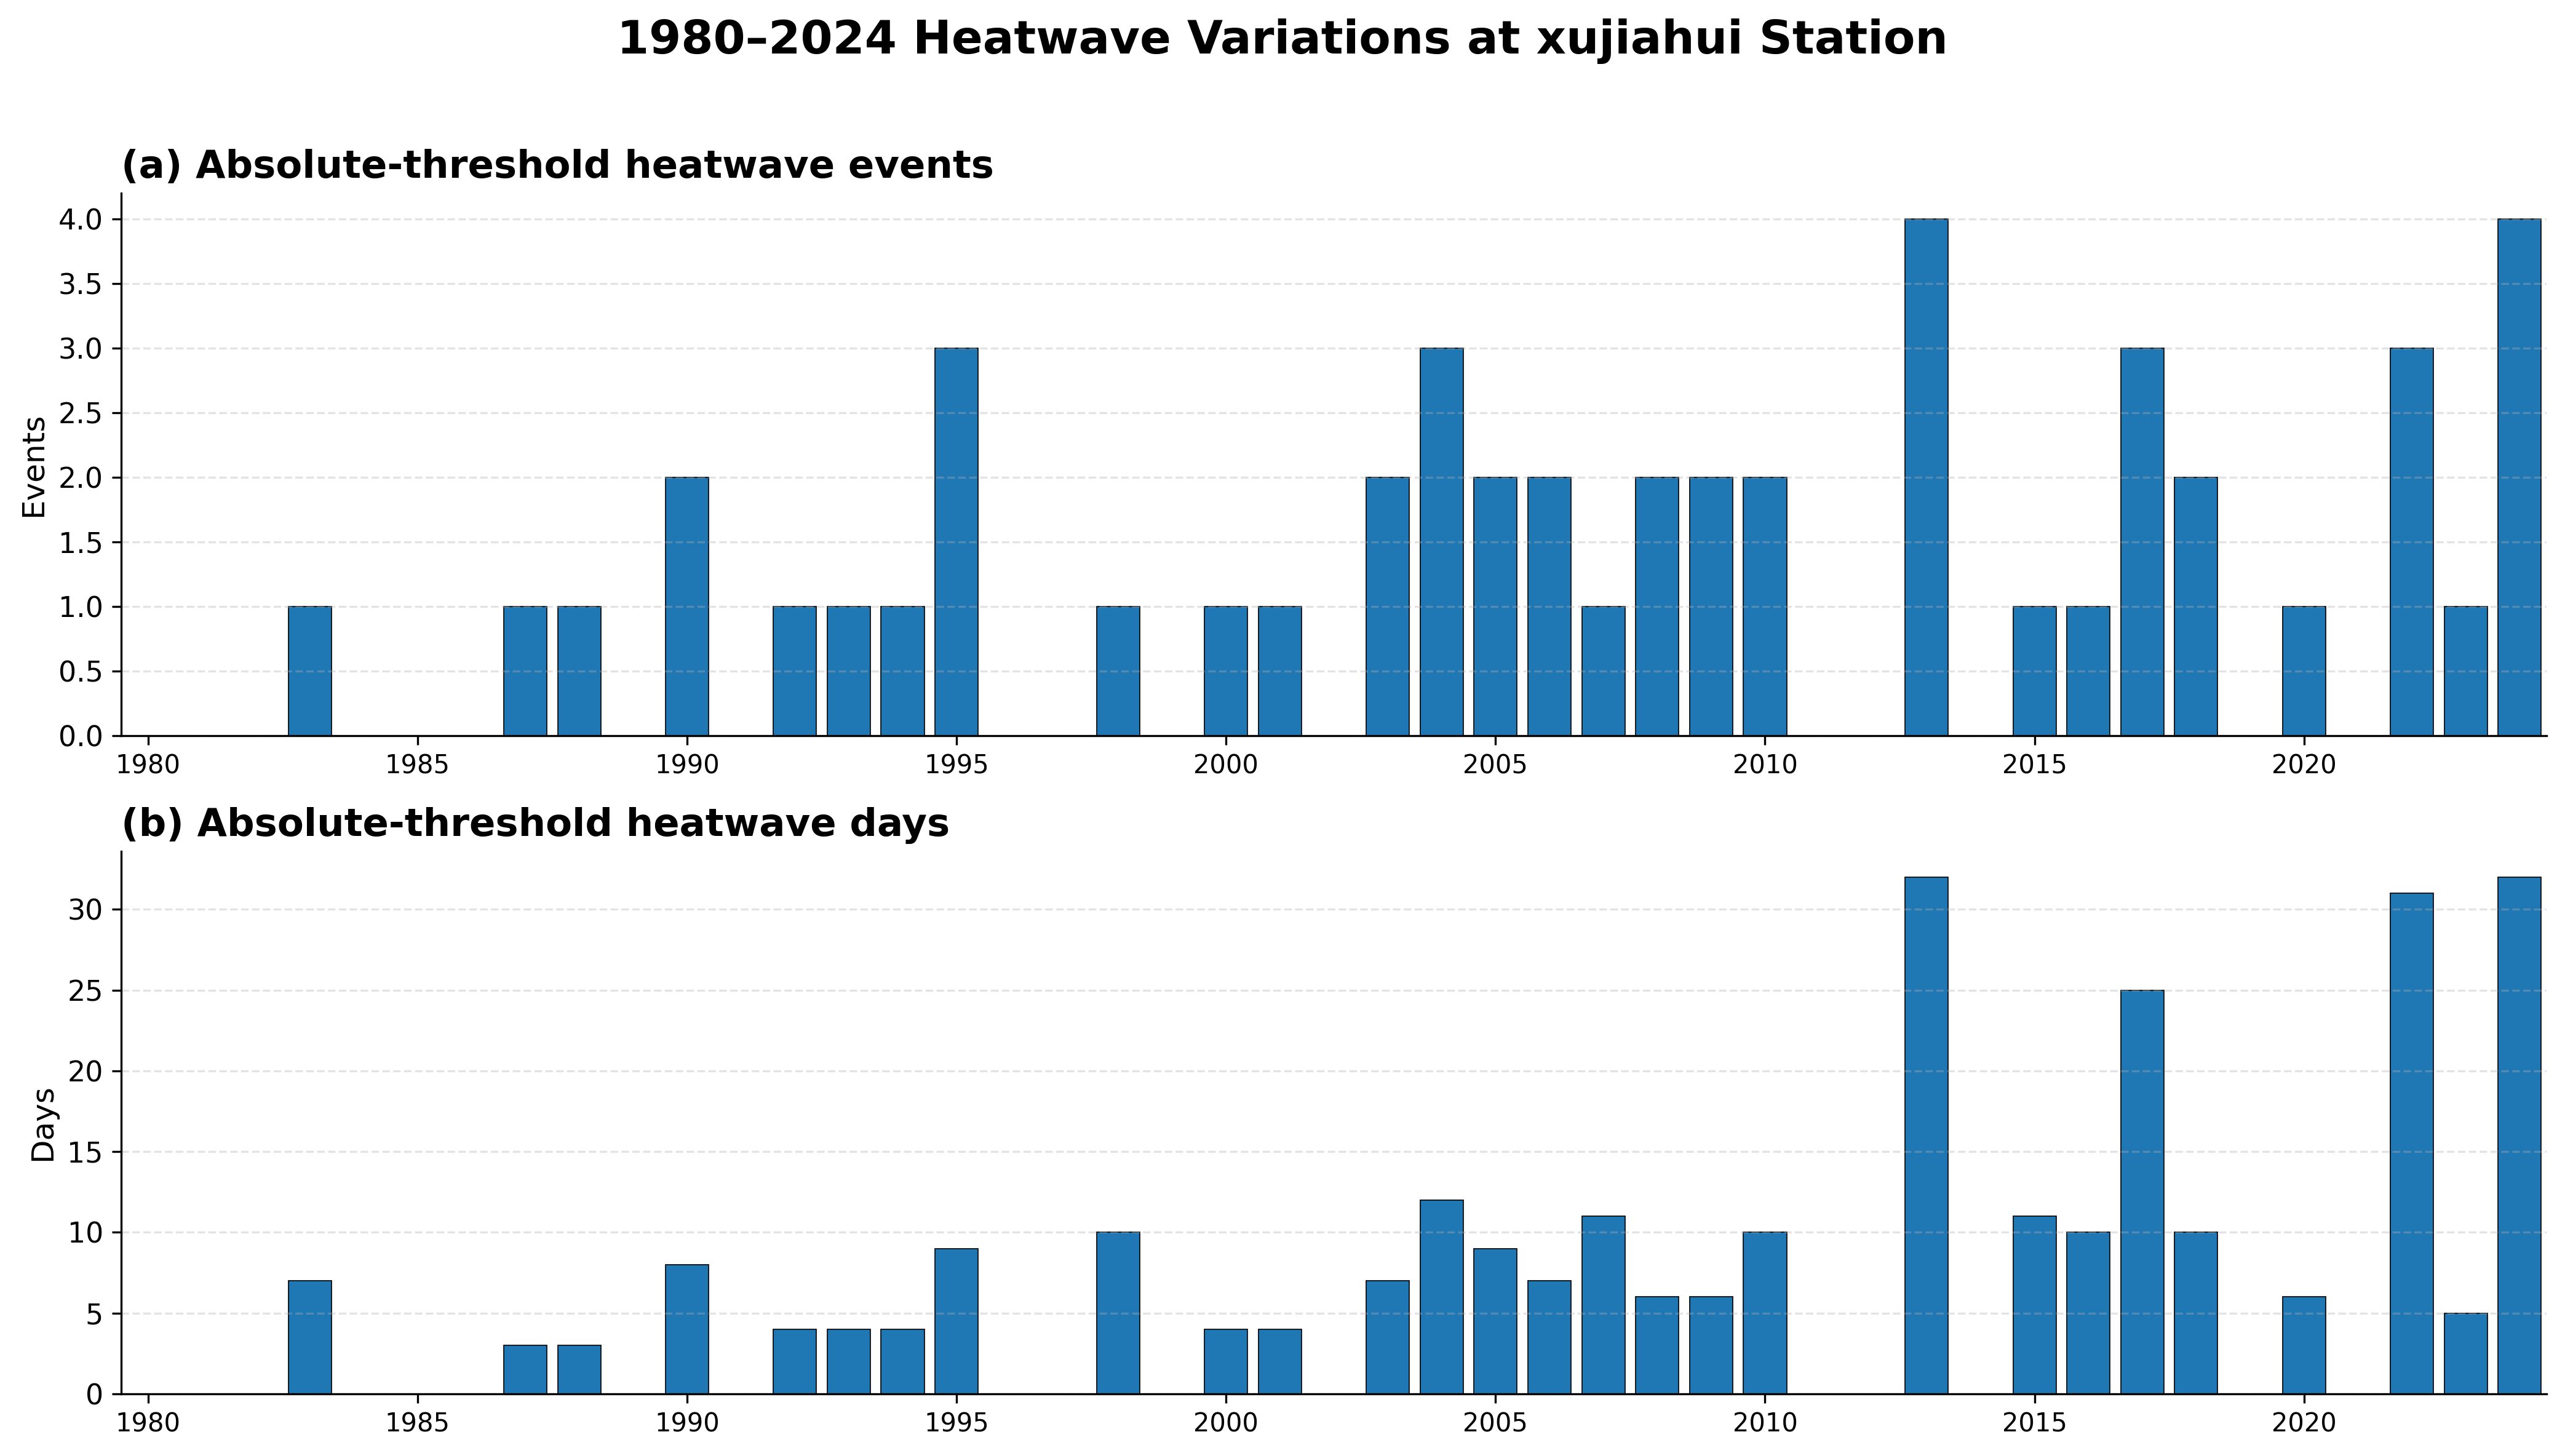

Figure saved:
/content/output/xujiahui_absolute_heatwave_timeseries.png


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import os

# =====================================================
# 0. Parameters
# =====================================================
CSV_FILE = r"/content/output/xujiahui_Annual_Heatwave_Statistics.csv"

OUTPUT_DIR = r"/content/output"

SITE_NAME = "xujiahui"

# Options:
# "absolute" → absolute threshold
# "relative" → relative threshold
# "both"     → both types
PLOT_MODE = "absolute"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =====================================================
# 1. Global settings
# =====================================================
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["axes.unicode_minus"] = False

# =====================================================
# 2. Read data
# =====================================================
df = pd.read_csv(CSV_FILE)

years = df["Year"]

# =====================================================
# 3. Configure plot mode
# =====================================================
if PLOT_MODE == "absolute":

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(14, 8),
        dpi=300
    )

    data_list = [
        (
            df["Absolute_HW_Events"],
            "(a) Absolute-threshold heatwave events",
            "Events"
        ),
        (
            df["Absolute_HW_Days"],
            "(b) Absolute-threshold heatwave days",
            "Days"
        )
    ]

    output_name = f"{SITE_NAME}_absolute_heatwave_timeseries.png"

elif PLOT_MODE == "relative":

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(14, 8),
        dpi=300
    )

    data_list = [
        (
            df["Relative_HW_Events"],
            "(a) Relative-threshold heatwave events",
            "Events"
        ),
        (
            df["Relative_HW_Days"],
            "(b) Relative-threshold heatwave days",
            "Days"
        )
    ]

    output_name = f"{SITE_NAME}_relative_heatwave_timeseries.png"

elif PLOT_MODE == "both":

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(15, 9),
        dpi=300
    )

    axes = axes.flatten()

    data_list = [
        (
            df["Absolute_HW_Events"],
            "(a) Absolute-threshold heatwave events",
            "Events"
        ),
        (
            df["Absolute_HW_Days"],
            "(b) Absolute-threshold heatwave days",
            "Days"
        ),
        (
            df["Relative_HW_Events"],
            "(c) Relative-threshold heatwave events",
            "Events"
        ),
        (
            df["Relative_HW_Days"],
            "(d) Relative-threshold heatwave days",
            "Days"
        )
    ]

    output_name = f"{SITE_NAME}_both_heatwave_timeseries.png"

else:
    raise ValueError("PLOT_MODE must be 'absolute', 'relative', or 'both'")

# =====================================================
# 4. Plot
# =====================================================
for ax, (data, title, ylabel) in zip(axes, data_list):

    ax.bar(
        years,
        data,
        width=0.8,
        edgecolor="black",
        linewidth=0.4
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        loc="left"
    )

    ax.set_ylabel(
        ylabel,
        fontsize=12
    )

    ax.set_xlim(1979.5, 2024.5)

    ax.set_xticks(np.arange(1980, 2025, 5))

    ax.tick_params(
        axis='x',
        labelsize=10
    )

    ax.tick_params(
        axis='y',
        labelsize=11
    )

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.35
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# =====================================================
# 5. Figure title
# =====================================================
fig.suptitle(
    f"1980–2024 Heatwave Variations at {SITE_NAME} Station",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# =====================================================
# 6. Save figure
# =====================================================
output_path = os.path.join(
    OUTPUT_DIR,
    output_name
)

plt.savefig(
    output_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:")
print(output_path)

**5.Daytime, nighttime, and compound heatwave calculation and plotting**

Data loaded successfully
Time range: 1980-01-01 08:00:00 -> 2024-12-31 23:00:00
Daily Tmax/Tmin generated
Daily records: 16436


Annual summary saved:
/content/output/xujiahui_annual_heatwave_summary.csv
Daily flag file saved:
/content/output/xujiahui_daily_heatwave_flags.csv


Figure saved:
/content/output/xujiahui_heatwave_changes.png


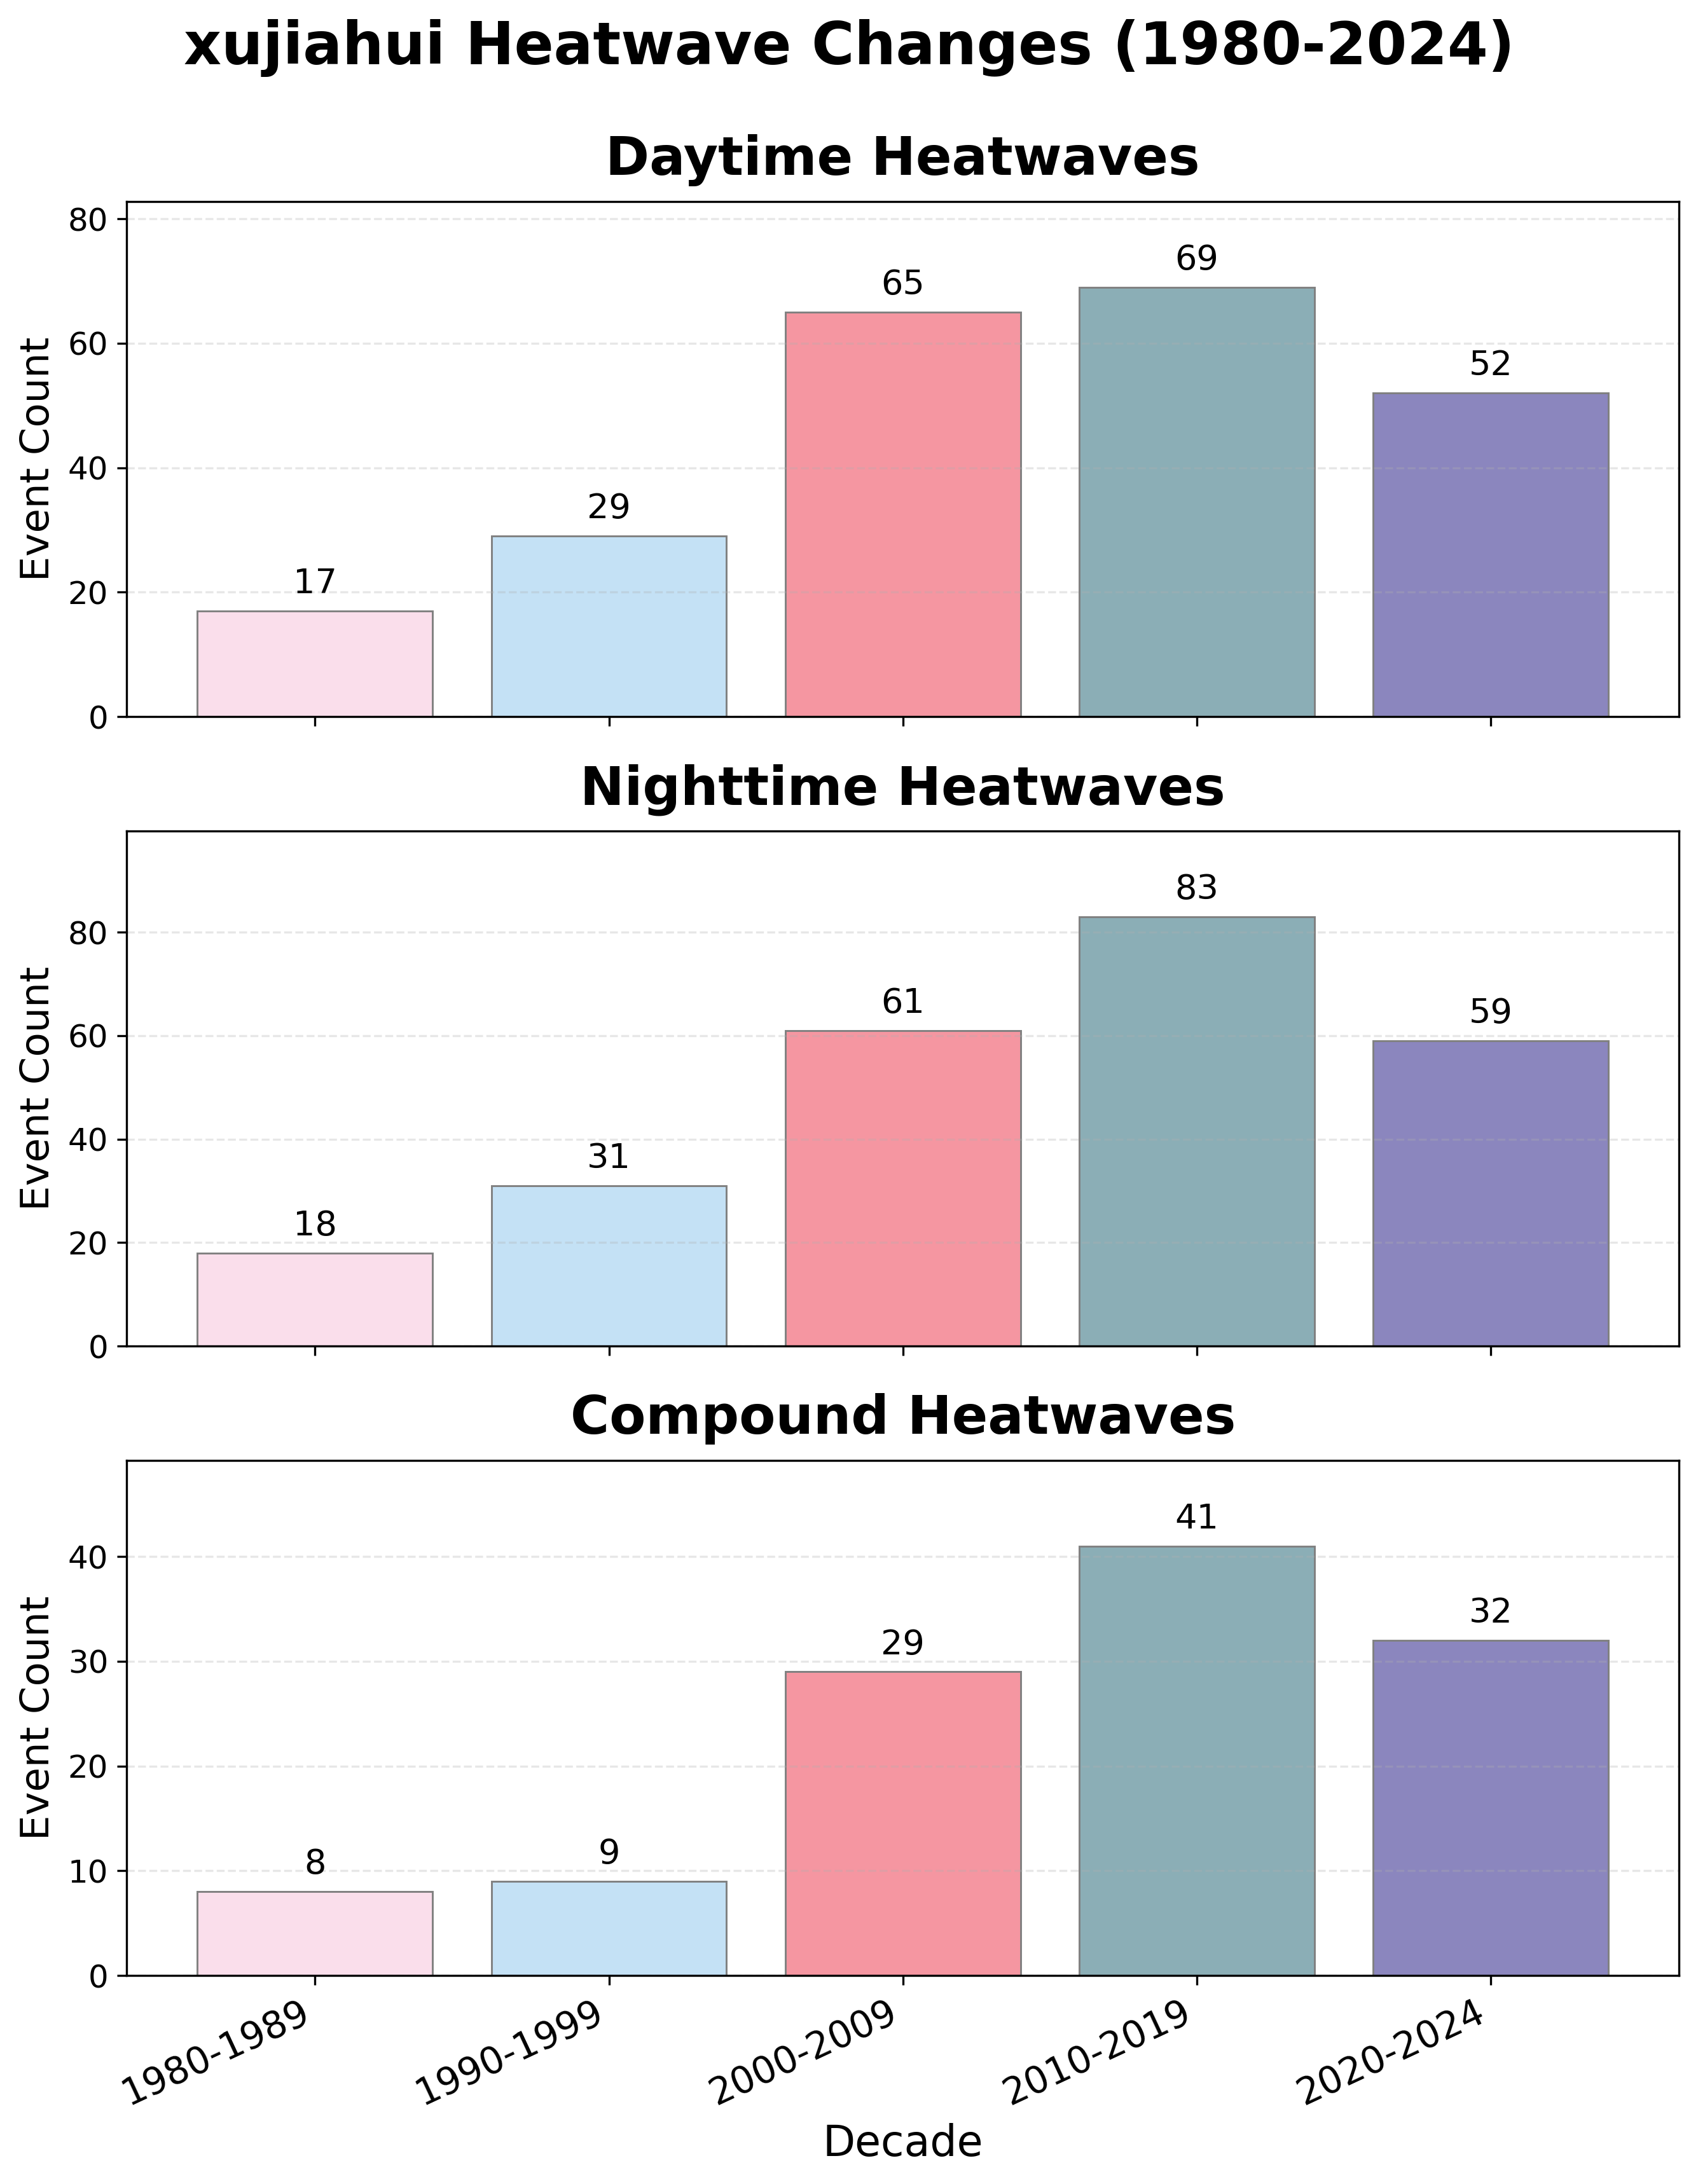

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# =====================================================
# 0. Settings
# =====================================================
INPUT_FILE = r"/content/80-24_xujiahui.csv"
OUTPUT_DIR = r"/content/output"

STATION_NAME = "xujiahui"

TEMP_COL = "Corrected_temperature_C"

START_YEAR = 1980
END_YEAR = 2024

BASELINE_START = 1981
BASELINE_END = 2010

PERCENTILE = 90
WINDOW_SIZE = 15
MIN_DURATION = 3

METRIC = "Event_Count"

os.makedirs(OUTPUT_DIR, exist_ok=True)

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["axes.unicode_minus"] = False

# =====================================================
# 1. Read hourly temperature data
# =====================================================
df = pd.read_csv(INPUT_FILE)

df.columns = df.columns.str.strip()

df["datetime"] = pd.to_datetime(
    {
        "year": df["Year"],
        "month": df["Month"],
        "day": df["Day"],
        "hour": df["Hour"]
    },
    errors="coerce"
)

df = df.dropna(subset=["datetime", TEMP_COL]).copy()

df["date"] = df["datetime"].dt.date
df["year"] = df["datetime"].dt.year

df = df[
    (df["year"] >= START_YEAR) &
    (df["year"] <= END_YEAR)
].copy()

print("Data loaded successfully")
print("Time range:", df["datetime"].min(), "->", df["datetime"].max())

# =====================================================
# 2. Generate daily Tmax and Tmin
# =====================================================
daily = (
    df.groupby("date")
    .agg(
        Tmax=(TEMP_COL, "max"),
        Tmin=(TEMP_COL, "min"),
        Hour_Count=(TEMP_COL, "count")
    )
    .reset_index()
)

daily["date"] = pd.to_datetime(daily["date"])
daily["year"] = daily["date"].dt.year
daily["doy"] = daily["date"].dt.dayofyear

daily = daily[daily["Hour_Count"] >= 18].copy()

print("Daily Tmax/Tmin generated")
print("Daily records:", len(daily))

# =====================================================
# 3. Calculate percentile thresholds
# =====================================================
def get_thresholds(daily_df, value_col):
    base = daily_df[
        (daily_df["year"] >= BASELINE_START) &
        (daily_df["year"] <= BASELINE_END)
    ].copy()

    thresholds = {}

    for doy in range(1, 367):
        half = WINDOW_SIZE // 2
        window_days = []

        for offset in range(-half, half + 1):
            d = doy + offset

            if d < 1:
                d += 366
            elif d > 366:
                d -= 366

            window_days.append(d)

        vals = base.loc[
            base["doy"].isin(window_days),
            value_col
        ].dropna()

        if len(vals) > 0:
            thresholds[doy] = np.percentile(vals, PERCENTILE)
        else:
            thresholds[doy] = np.nan

    return thresholds


tmax_thresholds = get_thresholds(daily, "Tmax")
tmin_thresholds = get_thresholds(daily, "Tmin")

daily["Tmax_P90"] = daily["doy"].map(tmax_thresholds)
daily["Tmin_P90"] = daily["doy"].map(tmin_thresholds)

# =====================================================
# 4. Heatwave definitions
# =====================================================
daily["Daytime_HW"] = daily["Tmax"] >= daily["Tmax_P90"]
daily["Nighttime_HW"] = daily["Tmin"] >= daily["Tmin_P90"]
daily["Compound_HW"] = daily["Daytime_HW"] & daily["Nighttime_HW"]

# =====================================================
# 5. Heatwave event statistics
# =====================================================
def summarize_events(daily_df, flag_col, event_name):
    records = []

    for year, group in daily_df.groupby("year"):
        group = group.sort_values("date").copy()
        flags = group[flag_col].values

        event_count = 0
        hw_days = 0
        i = 0

        while i < len(flags):
            if flags[i]:
                start = i

                while i < len(flags) and flags[i]:
                    i += 1

                end = i
                duration = end - start

                if duration >= MIN_DURATION:
                    event_count += 1
                    hw_days += duration
            else:
                i += 1

        records.append({
            "Station": STATION_NAME,
            "Year": year,
            "Type": event_name,
            "Event_Count": event_count,
            "HW_Days": hw_days
        })

    return pd.DataFrame(records)


day_summary = summarize_events(daily, "Daytime_HW", "Daytime Heatwaves")
night_summary = summarize_events(daily, "Nighttime_HW", "Nighttime Heatwaves")
compound_summary = summarize_events(daily, "Compound_HW", "Compound Heatwaves")

summary = pd.concat(
    [day_summary, night_summary, compound_summary],
    ignore_index=True
)

# =====================================================
# 6. Save annual statistics
# =====================================================
summary_out = os.path.join(
    OUTPUT_DIR,
    f"{STATION_NAME}_annual_heatwave_summary.csv"
)

daily_out = os.path.join(
    OUTPUT_DIR,
    f"{STATION_NAME}_daily_heatwave_flags.csv"
)

summary.to_csv(summary_out, index=False, encoding="utf-8-sig")
daily.to_csv(daily_out, index=False, encoding="utf-8-sig")

print("Annual summary saved:")
print(summary_out)

print("Daily flag file saved:")
print(daily_out)

# =====================================================
# 7. Decade statistics
# =====================================================
decades = [
    "1980-1989",
    "1990-1999",
    "2000-2009",
    "2010-2019",
    "2020-2024"
]

def get_decade_label(year):
    if 1980 <= year <= 1989:
        return "1980-1989"
    elif 1990 <= year <= 1999:
        return "1990-1999"
    elif 2000 <= year <= 2009:
        return "2000-2009"
    elif 2010 <= year <= 2019:
        return "2010-2019"
    elif 2020 <= year <= 2024:
        return "2020-2024"
    else:
        return np.nan


summary["Decade"] = summary["Year"].apply(get_decade_label)

decade_summary = (
    summary
    .dropna(subset=["Decade"])
    .groupby(["Type", "Decade"], as_index=False)[METRIC]
    .sum()
)

# =====================================================
# 8. Plot
# =====================================================
types = [
    "Daytime Heatwaves",
    "Nighttime Heatwaves",
    "Compound Heatwaves"
]

colors = [
    "#FADEEB",
    "#C4E1F5",
    "#F596A1",
    "#8BAEB6",
    "#8B86BE"
]

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 12),
    sharex=True
)

plt.subplots_adjust(hspace=0.40)

x = np.arange(len(decades))

for ax, hw_type in zip(axes, types):

    sub = decade_summary[
        decade_summary["Type"] == hw_type
    ].copy()

    values = []

    for dec in decades:
        val = sub.loc[
            sub["Decade"] == dec,
            METRIC
        ]

        if len(val) > 0:
            values.append(float(val.iloc[0]))
        else:
            values.append(0)

    bars = ax.bar(
        x,
        values,
        color=colors,
        edgecolor="gray",
        linewidth=0.7
    )

    max_value = max(values) if max(values) > 0 else 1

    ax.set_ylim(0, max_value * 1.20)

    for bar, value in zip(bars, values):
        if value > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max_value * 0.025,
                f"{value:.0f}",
                ha="center",
                va="bottom",
                fontsize=13,
                clip_on=False
            )

    ax.set_title(
        hw_type,
        fontsize=20,
        fontweight="bold",
        pad=10
    )

    ax.set_ylabel(
        METRIC.replace("_", " "),
        fontsize=15
    )

    ax.tick_params(axis="y", labelsize=12)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

axes[-1].set_xticks(x)

axes[-1].set_xticklabels(
    decades,
    rotation=25,
    ha="right",
    fontsize=14
)

axes[-1].set_xlabel(
    "Decade",
    fontsize=16
)

fig.suptitle(
    f"{STATION_NAME} Heatwave Changes (1980-2024)",
    fontsize=22,
    fontweight="bold",
    y=0.95
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

fig_out = os.path.join(
    OUTPUT_DIR,
    f"{STATION_NAME}_heatwave_changes.png"
)

plt.savefig(
    fig_out,
    dpi=300,
    bbox_inches="tight"
)

print("Figure saved:")
print(fig_out)

plt.show()